# Deep Learning Fundamentals - Mini-Project

## MNIST Digits - MLP Result Metrics

# 0. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import torch
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

from mnist_datamodule import MNISTDataModule
from mnist_mlp_classifier import MNISTMLP

# 1. Checkpoints best Result

In [2]:
CKPT_PATH = "checkpoints/mnist_mlp_best.ckpt"
CLASS_NAMES = [str(i) for i in range(10)]

In [3]:
model = MNISTMLP.load_from_checkpoint(CKPT_PATH)
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

MNISTMLP(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=1024, out_features=1024, bias=True)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=1024, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.1, inplace=False)
  )
  (head): Linear(in_features=1024, out_features=10, bias=True)
  (criterion): CrossEntropyLoss()
  (acc_tr): MulticlassAccuracy()
  (acc_va): MulticlassAccuracy()
  (acc_te): MulticlassAccuracy()
)

### Loading and Summary 
- Loaded the best checkpoint and switched the model to eval() on the available device (GPU if present).
- The printed summary confirms the selected architecture: 3 hidden blocks of Linear(784→1024) → BatchNorm1d → - LeakyReLU(0.01) → Dropout(0.1), followed by a Linear(1024→10) head and CrossEntropyLoss, with accuracy metrics for train/val/test.

In [4]:
dm = MNISTDataModule(batch_size=256, augment=False)
dm.prepare_data(); dm.setup()

In [5]:
device = next(model.parameters()).device
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in dm.test_dataloader():
        x = x.to(device); y = y.to(device)
        logits = model(x)
        y_true.append(y.cpu().numpy())
        y_pred.append(logits.argmax(dim=1).cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

### Model evaluation on test set
- Creates the MNIST test loader (no augmentation) and runs inference in `torch.no_grad()`.  
- Each batch is sent to the available device, and both ground-truth (`y_true`) and predicted labels (`y_pred`) are collected via `argmax` over logits.  
- Batch size = 256 is used for efficient evaluation without affecting results.


Using metrics: logs/mnist_mlp_final/version_1/metrics.csv


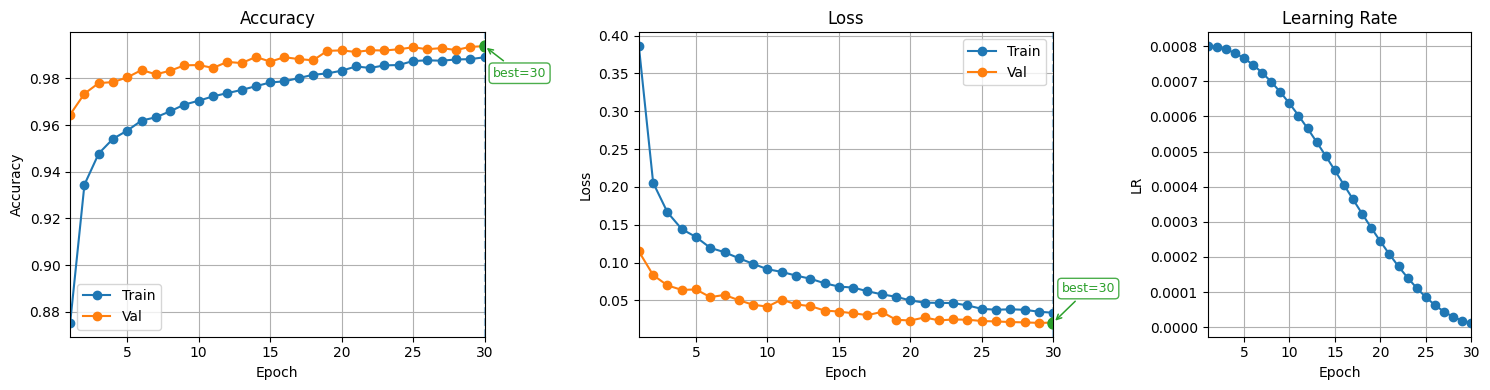

In [6]:
LOG_ROOT = "logs/mnist_mlp_final"

version_dirs = []
for root, dirs, files in os.walk(LOG_ROOT):
    version_dirs += [os.path.join(root, d) for d in dirs if d.startswith("version_")]
assert version_dirs, f"No lightning CSV logs found under '{LOG_ROOT}/'."
version_path = sorted(version_dirs, key=lambda p: int(os.path.basename(p).split("_")[-1]))[-1]
metrics_csv = os.path.join(version_path, "metrics.csv")
print("Using metrics:", metrics_csv)

df = pd.read_csv(metrics_csv)

def last_per_epoch(df_in: pd.DataFrame, col: str) -> pd.DataFrame:
    if col not in df_in.columns:
        return pd.DataFrame(columns=["epoch", col])
    tmp = df_in.loc[~df_in[col].isna(), ["epoch", col]]
    return tmp.groupby("epoch", as_index=False).last()

# Resolve possible column name variants
val_acc_col  = "val_acc"    if "val_acc"    in df.columns else ("val_acc_epoch"    if "val_acc_epoch"    in df.columns else None)
trn_acc_col  = "train_acc"  if "train_acc"  in df.columns else ("train_acc_epoch"  if "train_acc_epoch"  in df.columns else None)
val_loss_col = "val_loss"   if "val_loss"   in df.columns else ("val_loss_epoch"   if "val_loss_epoch"   in df.columns else None)
trn_loss_col = "train_loss" if "train_loss" in df.columns else ("train_loss_epoch" if "train_loss_epoch" in df.columns else None)
lr_col       = "lr" if "lr" in df.columns else None

acc_val  = last_per_epoch(df, val_acc_col)  if val_acc_col  else pd.DataFrame(columns=["epoch","val_acc"])
acc_tr   = last_per_epoch(df, trn_acc_col)  if trn_acc_col  else pd.DataFrame(columns=["epoch","train_acc"])
loss_val = last_per_epoch(df, val_loss_col) if val_loss_col else pd.DataFrame(columns=["epoch","val_loss"])
loss_tr  = last_per_epoch(df, trn_loss_col) if trn_loss_col else pd.DataFrame(columns=["epoch","train_loss"])
lr_ep    = last_per_epoch(df, lr_col)       if lr_col       else pd.DataFrame(columns=["epoch","lr"])

# Normalize column names so plotting code is simple
if not acc_val.empty:  acc_val.rename(columns={val_acc_col: "val_acc"}, inplace=True)
if not acc_tr.empty:   acc_tr.rename(columns={trn_acc_col: "train_acc"}, inplace=True)
if not loss_val.empty: loss_val.rename(columns={val_loss_col: "val_loss"}, inplace=True)
if not loss_tr.empty:  loss_tr.rename(columns={trn_loss_col: "train_loss"}, inplace=True)
if not lr_ep.empty:    lr_ep.rename(columns={lr_col: "lr"}, inplace=True)

# Build 1-based epoch axis limits
epochs_all = set()
for d in (acc_val, acc_tr, loss_val, loss_tr, lr_ep):
    if not d.empty:
        epochs_all |= set(map(int, d["epoch"]))
assert epochs_all, "No epoch-level rows in CSV; check logging configuration."
x_min, x_max = 1, int(max(epochs_all) + 1)  # epochs shown as 1..N

# Pick a "best epoch": highest val_acc (tie-break by lowest val_loss); else min val_loss
if not acc_val.empty:
    merged = acc_val.merge(loss_val, on="epoch", how="left")
    top = merged["val_acc"].max()
    cands = merged[merged["val_acc"] == top]
    if "val_loss" in cands and not cands["val_loss"].isna().all():
        best_row = cands.sort_values("val_loss", ascending=True).iloc[0]
    else:
        best_row = cands.iloc[0]
    best_epoch = int(best_row["epoch"]) + 1
    best_val_acc  = float(best_row["val_acc"])
    best_val_loss = float(best_row["val_loss"]) if "val_loss" in best_row and not pd.isna(best_row["val_loss"]) else None
else:
    assert not loss_val.empty, "Need either val_acc or val_loss to choose a best epoch."
    idx = int(loss_val["val_loss"].idxmin())
    best_epoch = int(loss_val.loc[idx, "epoch"]) + 1
    best_val_acc = None
    best_val_loss = float(loss_val.loc[idx, "val_loss"])

# === Plot: Accuracy | Loss | LR ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [2.2, 2.2, 1.4]})

# Accuracy
ax1 = axes[0]
if not acc_tr.empty:  ax1.plot(acc_tr.epoch + 1,  acc_tr.train_acc, marker="o", label="Train")
if not acc_val.empty: ax1.plot(acc_val.epoch + 1, acc_val.val_acc,   marker="o", label="Val")
ax1.set_xlim(x_min, x_max)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.set_title("Accuracy")
ax1.grid(True); ax1.legend()

ax2 = axes[1]

if best_val_acc is not None:

    for ax in (ax1, ax2):
        ax.axvline(best_epoch, ls="--", alpha=0.25)

    ax1.plot(best_epoch, best_val_acc, marker="o", markersize=8, color="tab:green")
    y_min, y_max = ax1.get_ylim(); y_mid = 0.5*(y_min+y_max)
    dy = -22 if best_val_acc > y_mid else 22
    ax1.annotate(f"best={best_epoch}", (best_epoch, best_val_acc),
                 textcoords="offset points", xytext=(6, dy),
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="tab:green"),
                 arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.1),
                 fontsize=9, color="tab:green")

# Loss
if not loss_tr.empty:  ax2.plot(loss_tr.epoch + 1,  loss_tr.train_loss, marker="o", label="Train")
if not loss_val.empty: ax2.plot(loss_val.epoch + 1, loss_val.val_loss,  marker="o", label="Val")
ax2.set_xlim(x_min, x_max)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.set_title("Loss")
ax2.grid(True); ax2.legend()

if best_val_loss is not None:

    for ax in (ax1, ax2):
        ax.axvline(best_epoch, ls="--", alpha=0.25)

    ax2.plot(best_epoch, best_val_loss, marker="o", markersize=8, color="tab:green")
    y_min, y_max = ax2.get_ylim(); y_mid = 0.5*(y_min+y_max)
    # for loss (lower is better) flip the default arrow direction
    dy = 22 if best_val_loss < y_mid else -22
    ax2.annotate(f"best={best_epoch}", (best_epoch, best_val_loss),
                 textcoords="offset points", xytext=(6, dy),
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="tab:green"),
                 arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.1),
                 fontsize=9, color="tab:green")

# Learning rate (mini-plot)
ax3 = axes[2]
if not lr_ep.empty:
    ax3.plot(lr_ep.epoch + 1, lr_ep.lr, marker="o")
    ax3.set_xlim(x_min, x_max)
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("LR"); ax3.set_title("Learning Rate")
    ax3.grid(True)
else:
    ax3.axis("off")
    ax3.text(0.5, 0.5, "LR not logged", ha="center", va="center")

plt.tight_layout()
plt.show()

### Learning curves, best epoch and LR schedule
- *This cell loads the Lightning `metrics.csv`, reconciles column names, and plots Train/Val **accuracy** and **loss** per epoch. A dashed vertical line marks the **best epoch** (max validation accuracy; tie-break by min val loss) and the green callout labels it (best=30).*
- *The **learning-rate subplot** shows the cosine decay used during training, descending smoothly to near zero by the last epoch.*

**What the plots show**
- *Accuracy increases **monotonically** for both train and validation, with validation peaking at the end of the schedule (no late-epoch degradation).*
- *Loss decreases steadily on both splits; the **train–val gap remains small**, consistent with good generalization and no overfitting.*
- *The LR curve mirrors the smooth convergence behaviour—no oscillations—supporting the stability reported in the Evaluation section.*


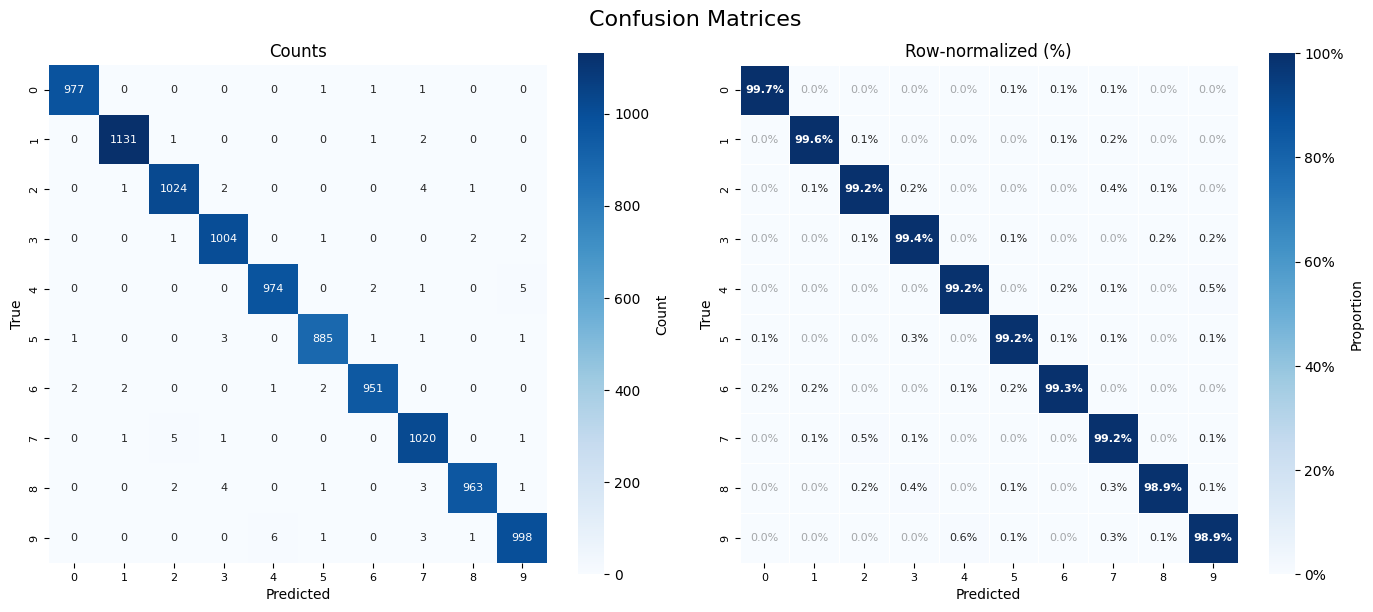

In [7]:
cm_counts = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_pct = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)), normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices", fontsize=16)

# Left chart: raw counts
ax = axes[0]
sns.heatmap(
    cm_counts, annot=True, fmt="d", cmap="Blues", cbar=True, square=True, ax=ax,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    annot_kws={"size": 8},
    cbar_kws={"label":"Count"}
)
ax.set_title("Counts", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Right chart: row-normalized percentages
ax = axes[1]
sns.heatmap(
    cm_pct, annot=True, fmt=".1%", cmap="Blues", cbar=True, square=True, ax=ax,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    vmin=0.0, vmax=1.0,
    cbar_kws={"format": PercentFormatter(1), "label": "Proportion"},
    annot_kws={"size": 8},
    linewidths=0.5, linecolor="white",
)

for (i, j), val in np.ndenumerate(cm_pct):
    txt = ax.texts[i * cm_pct.shape[1] + j]
    if i == j: txt.set_fontweight("bold")
    if val == 0.0: txt.set_alpha(0.4)

ax.set_title("Row-normalized (%)", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
# Set tick label font sizes after heatmap creation
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# Optional: quick summary of the most confused pair (off-diagonal)
mask = np.eye(cm_pct.shape[0], dtype=bool)
i, j = np.unravel_index(np.argmax(np.where(~mask, cm_pct, -1)), cm_pct.shape)

### Confusion matrices (counts & row-normalized)
- This cell computes two matrices with `sklearn.metrics.confusion_matrix`:  
  **left** = raw **counts**; **right** = **row-normalized** proportions (each row sums to 100%, i.e., P(pred | true)).  
  Diagonal cells are bolded on the right plot to highlight correct classifications.

**Key observations**
- Diagonals are very high across all digits (≈ **98.9%–99.7%**), confirming strong overall accuracy and low variance across classes.  
- Residual misclassifications are concentrated in perceptually similar pairs, predominantly **9 → 4**, **7 → 2**, **8 → 3/7**, and **5 → 3**; these align with the “look-alike” morphology noted in the DU section.  
- Errors are **asymmetric** (e.g., 9→4 is more frequent than 4→9), which is visible only in the row-normalized view.

**Note**
- The small code snippet after the plots extracts the **most confused off-diagonal pair** from the normalized matrix (e.g., `9 → 4` in this run).


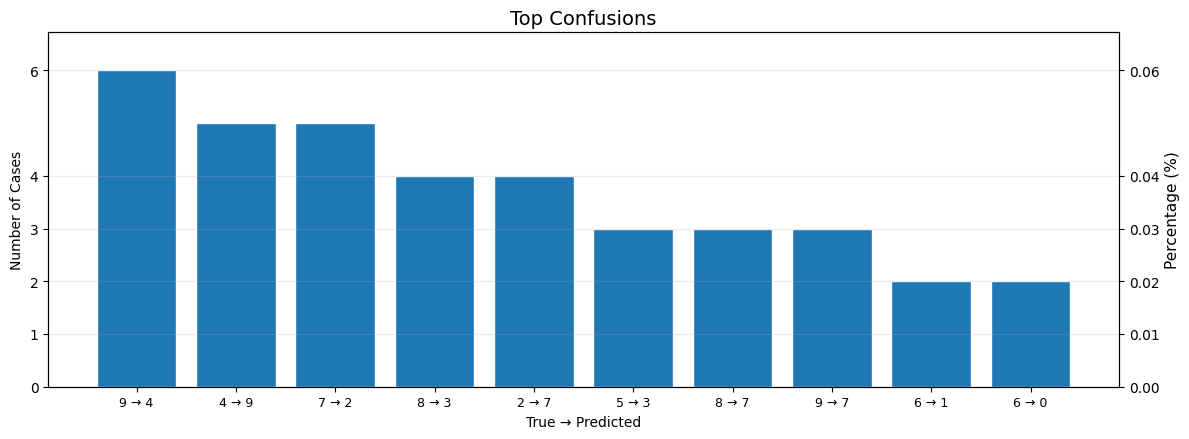

In [8]:
# ---- Build "top confusions" table from the confusion matrix ----
top_k = 10               # how many bars to show
use_percent = True       # True → rank by percentage; False → rank by raw counts

# 1) Flatten confusion matrix into pairs (i -> j), skipping the diagonal
pairs = []
n = cm_counts.shape[0]
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        count = int(cm_counts[i, j])
        pct   = float(cm_pct[i, j])  # 0..1 row-normalized
        if count > 0:
            pairs.append({
                "true": i,
                "pred": j,
                "count": count,
                "pct": pct,
                "pair": f"{CLASS_NAMES[i]} → {CLASS_NAMES[j]}",
            })

df_pairs = pd.DataFrame(pairs)

# Guard: if no off-diagonal errors exist (perfect classifier), avoid crash
if df_pairs.empty:
    print("No off-diagonal confusions found — model predictions are perfectly diagonal.")
else:
    # 2) Choose ranking metric
    if use_percent:
        df_pairs = df_pairs.sort_values("pct", ascending=False)
    else:
        df_pairs = df_pairs.sort_values("count", ascending=False)

    df_top = df_pairs.head(top_k).reset_index(drop=True)
    x_labels = df_top["pair"].tolist()

    # 3) Plot: counts (left axis) + % (right axis)
    import numpy as np
    import matplotlib.pyplot as plt

    fig_w = max(10, 1.2 * len(df_top))  # wider if many bars
    fig, ax1 = plt.subplots(figsize=(fig_w, 4.5))

    raw_counts = df_top["count"].to_numpy()
    indices = np.arange(len(raw_counts))

    bars = ax1.bar(indices, raw_counts, width=0.8, edgecolor="white")

    # Left y-axis: counts
    ax1.set_xticks(indices)
    ax1.set_xticklabels(x_labels, fontsize=9)
    ax1.set_xlabel("True → Predicted", fontsize=10)
    ax1.set_ylabel("Number of Cases", fontsize=10)
    ax1.set_title("Top Confusions", fontsize=14)
    ax1.grid(axis="y", alpha=0.25)

    # Right y-axis: percentages of total samples (not row-normalized)
    ax2 = ax1.twinx()
    total_all_data = int(cm_counts.sum())
    max_count = int(raw_counts.max()) if len(raw_counts) else 0
    margin_factor = 0.12

    # Sync y-lims with a small headroom
    ax1.set_ylim(0, max_count * (1 + margin_factor))

    # Percent scale relative to the entire dataset
    max_pct = (max_count / total_all_data) * 100 if total_all_data > 0 else 0.0
    ax2.set_ylim(0, max_pct * (1 + margin_factor))
    ax2.set_ylabel("Percentage (%)", fontsize=11)

    # Matched ticks on both axes
    ticks_count = np.linspace(0, max_count, 6, dtype=int)
    ticks_pct   = np.round((ticks_count / max(total_all_data, 1)) * 100, 2)
    ax1.set_yticks(ticks_count)
    ax2.set_yticks(ticks_pct)

    plt.subplots_adjust(bottom=0.28)
    plt.tight_layout()
    plt.show()


### Top confusions (ranked)
- This cell flattens the confusion matrix, removes the diagonal, ranks the **top-k misclassification pairs**, and plots them as a bar chart.  
- Left axis shows **raw counts** for each `True → Predicted` pair; the right axis shows the **percentage of the entire test set** these errors represent.

**Key observations from the plot**
- The dominant errors are **9 → 4**, **4 → 9**, **7 → 2**, **8 → 3**, **2 → 7**, and **5 → 3**; each occurs only a handful of times and corresponds to visually similar stroke patterns.  
- Each bar accounts for **≤ ~0.06%** of the whole test set, confirming that residual mistakes are **rare and localized**.


In [9]:
labels = list(range(len(CLASS_NAMES)))
n_total = len(y_true)

# Per-class metrics
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, zero_division=0
)

per_class = pd.DataFrame({
    "class": CLASS_NAMES,                     # aligned with `labels` order
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": support.astype(int),
    "prevalence": support / max(n_total, 1), # fraction of dataset
})

# Aggregates
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="micro", zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

accuracy = float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

avg_rows = pd.DataFrame([
    {"class": "macro avg",    "precision": macro_p,    "recall": macro_r,    "f1": macro_f1,    "support": int(support.sum()), "prevalence": support.sum()/max(n_total,1)},
    {"class": "micro avg",    "precision": micro_p,    "recall": micro_r,    "f1": micro_f1,    "support": int(support.sum()), "prevalence": support.sum()/max(n_total,1)},
    {"class": "weighted avg", "precision": weighted_p, "recall": weighted_r, "f1": weighted_f1, "support": int(support.sum()), "prevalence": support.sum()/max(n_total,1)},
    {"class": "accuracy",     "precision": accuracy,   "recall": accuracy,   "f1": accuracy,    "support": int(support.sum()), "prevalence": 1.0},
])

# Display with consistent rounding
cols_order = ["class", "precision", "recall", "f1", "support", "prevalence"]
display(pd.concat([per_class, avg_rows], ignore_index=True)[cols_order]
        .assign(prevalence=lambda d: d["prevalence"].round(4))
        .round({"precision": 4, "recall": 4, "f1": 4}))


,class,precision,recall,f1,support,prevalence
0,0,0.9969,0.9969,0.9969,980,0.0980
1,1,0.9965,0.9965,0.9965,1135,0.1135
2,2,0.9913,0.9922,0.9918,1032,0.1032
3,3,0.9901,0.9941,0.9921,1010,0.1010
4,4,0.9929,0.9919,0.9924,982,0.0982
5,5,0.9933,0.9922,0.9927,892,0.0892
6,6,0.9948,0.9927,0.9937,958,0.0958
7,7,0.9855,0.9922,0.9889,1028,0.1028
8,8,0.9959,0.9887,0.9923,974,0.0974
9,9,0.9901,0.9891,0.9896,1009,0.1009


### Per-class metrics (precision/recall/F1)

- Computes **precision, recall, F1 and support** per digit using `precision_recall_fscore_support` and then adds **macro/micro/weighted** aggregates and overall **accuracy**.
- Results are **uniformly high (~0.99 F1)** across classes; class **“7”** is the lowest (F1 ≈ 0.989) but still >0.988, consistent with the confusion pairs (e.g., 7→2).
- **Macro, micro and weighted F1 ≈ 0.9927**, confirming that performance is **evenly distributed** and not driven by a single class.
- **Support/prevalence ≈ 1k / 0.10** per class reflects the balanced MNIST test set, so macro = micro ≈ weighted as expected.
